In [1]:
import HPLC

chrom = HPLC.load("./data/EGG_HILIC_GlcNAc_0.2mM_20ul_80%MeCN_pH3_20mM_NH4OHC13.03.2026 17-17-16.dat")
chrom.display()
chrom = chrom.identify_peaks()

chrom.list_peaks()

pNPS = HPLC.compound(rt = 3.5, spread = 0.1, rf = 1000)
pNP = HPLC.compound(rt = 0.3, spread = 0.1, rf = lambda area: 10000 * area ** 2)

GlcNAc_part_1 = HPLC.compound(rt = 3.76, spread = 0.1, rf = lambda area: 5600 * area ** 2)
GlcNAc_part_2 = HPLC.compound(rt = 4.34, spread = 0.1, rf = lambda area: 3400 * area ** 2)
GlcNAc = HPLC.compounds.composite([GlcNAc_part_1,GlcNAc_part_2])

chrom = chrom.associate_compounds([pNPS,pNP, GlcNAc]).display()
chrom.display_publication_graph(filename = "publication_chromatogram.png")

ModuleNotFoundError: No module named 'HPLC'

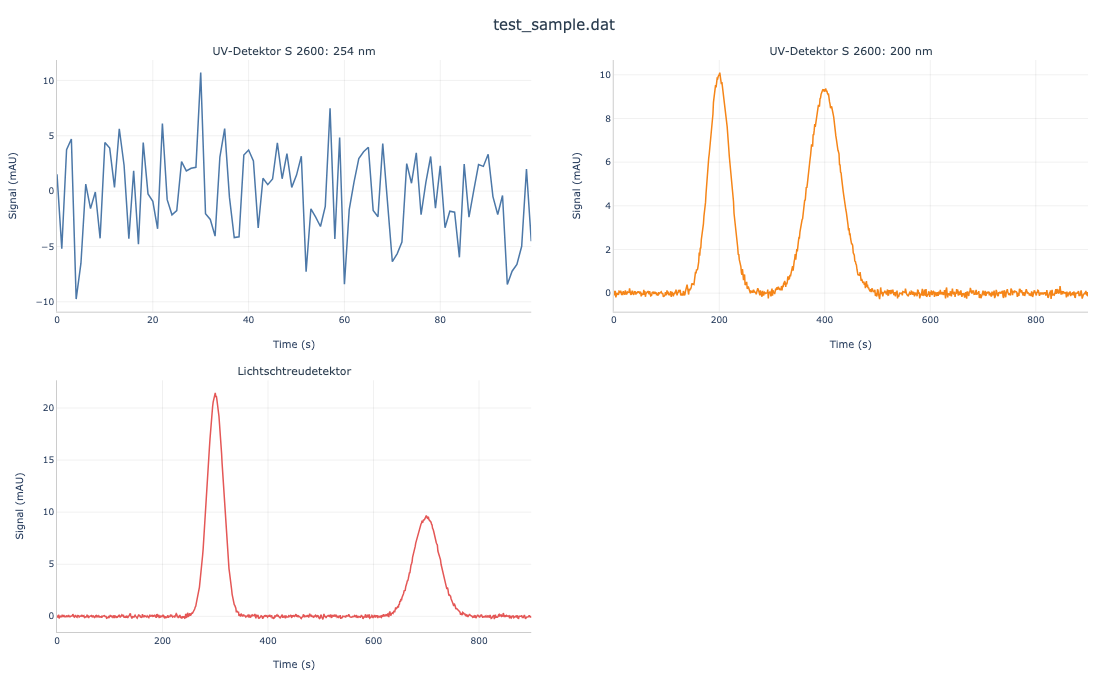

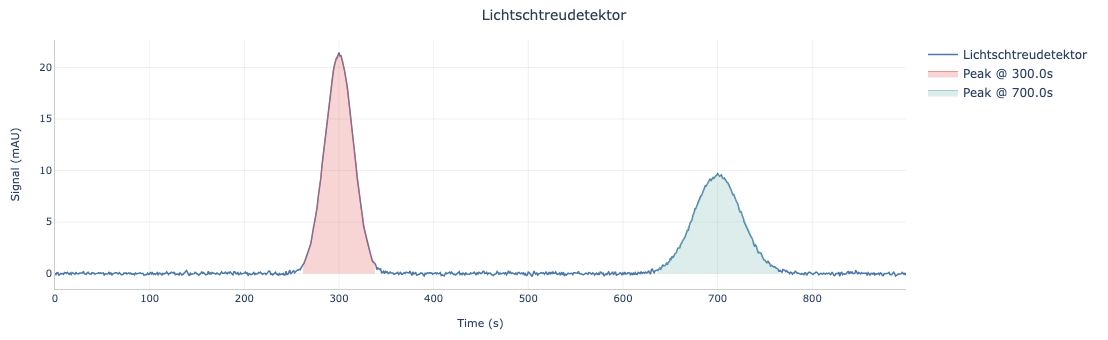

In [1]:
import HPLC
import numpy as np
import numpy as np
from scipy.special import erf
from HPLC.models.signal import Signal2D
from HPLC.models.chromatogram import Chromatogram
from HPLC.testing.mock_generators import make_raw_signal, make_signal2d, expected_peak_properties, make_chromatogram

DIFFICULT_PEAKS = [
    {"mu": 800, "amplitude": 80,  "sigma": 8,  "alpha": -10.0},  # extreme fronting
    {"mu": 200, "amplitude": 100, "sigma": 12, "alpha": 0.0},    # symmetric
    {"mu": 350, "amplitude": 60,  "sigma": 12, "alpha": 5.0},    # tailing
    {"mu": 480, "amplitude": 90,  "sigma": 12, "alpha": 3.0},    # mild tailing
]
NOISE = 0
DURATION = 1200

# make_signal2d(DIFFICULT_PEAKS, noise_scale=NOISE, duration=1200).display()

make_chromatogram({
        "UV-Detektor S 2600: 254 nm": {"peaks": [], "noise_scale": 5, "duration":100},
        "UV-Detektor S 2600: 200 nm": {"peaks": [
            {"mu": 200, "amplitude": 500, "sigma": 20, "alpha": 0.0},
            {"mu": 400, "amplitude": 700, "sigma": 30, "alpha": 0.0},
        ]},
        "Lichtschtreudetektor": {"peaks": [
            {"mu": 300, "amplitude": 800, "sigma": 15, "alpha": 0.0},
            {"mu": 700, "amplitude": 600, "sigma": 25, "alpha": 0.0},
        ]},
    }).display().detect_peaks().signals["Lichtschtreudetektor"].display()

In [2]:
make_chromatogram({
        "UV-Detektor S 2600: 254 nm": {"peaks": [], "noise_scale": 5},
        "UV-Detektor S 2600: 200 nm": {"peaks": [
            {"mu": 200, "amplitude": 500, "sigma": 20, "alpha": 0.0},
            {"mu": 400, "amplitude": 700, "sigma": 30, "alpha": 0.0},
        ]},
        "Lichtschtreudetektor": {"peaks": [
            {"mu": 300, "amplitude": 800, "sigma": 15, "alpha": 0.0},
            {"mu": 700, "amplitude": 600, "sigma": 25, "alpha": 0.0},
        ]},
    }).display()

NameError: name 'make_chromatogram' is not defined

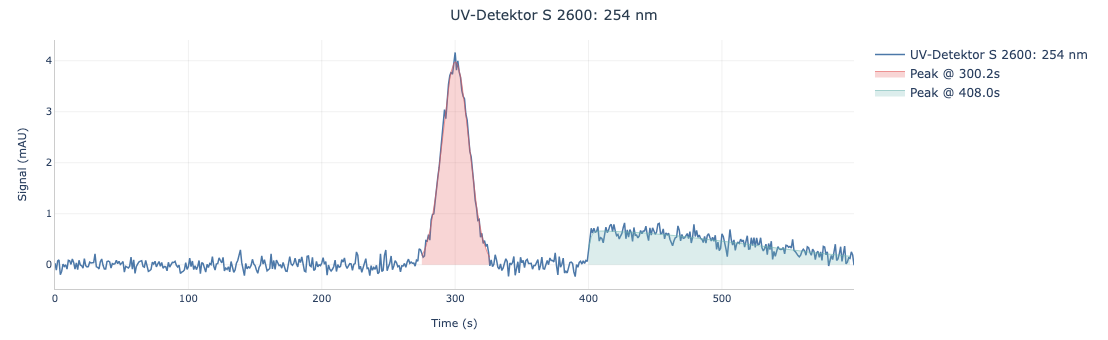

In [2]:
peaks_input = [{"mu": 400, "amplitude": 100, "sigma": 120, "alpha": 100.0},{"mu": 300, "amplitude": 100, "sigma": 10, "alpha": 0.0}]
make_signal2d(peaks_input, noise_scale=0.1, duration=600).detect_peaks().display()

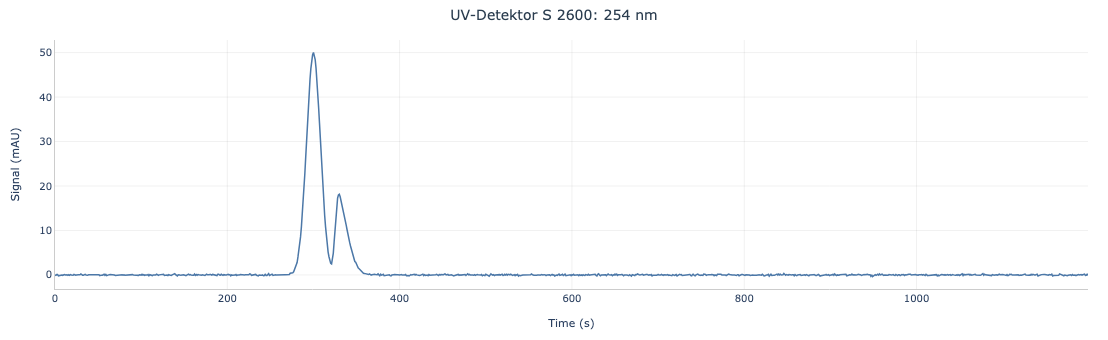

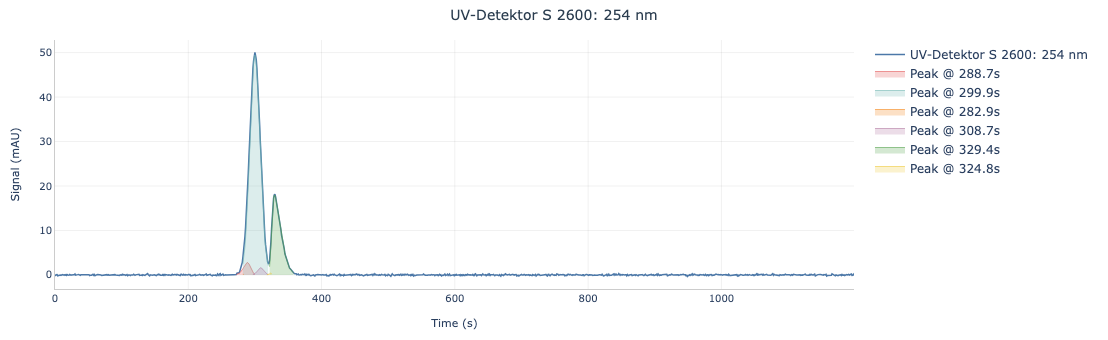

In [18]:

OVERLAP_HARD_PEAKS = [
    # {"mu": 500, "amplitude": 800,  "sigma": 120, "alpha": 30.0},
    {"mu": 300, "amplitude": 1000, "sigma": 8,  "alpha": 0.0},
    {"mu": 325, "amplitude": 300,  "sigma": 12,  "alpha": 5.0},
    # {"mu": 480, "amplitude": 900,  "sigma": 12,  "alpha": 3.0},
    # {"mu": 600, "amplitude": 900,  "sigma": 10,  "alpha": 0.0},
    # {"mu": 630, "amplitude": 200,  "sigma": 10,  "alpha": 0.0},
]
NOISE = 0.1
DURATION = 1200

make_signal2d(OVERLAP_HARD_PEAKS, noise_scale=NOISE, duration=DURATION).display().detect_peaks().display(width=1000)

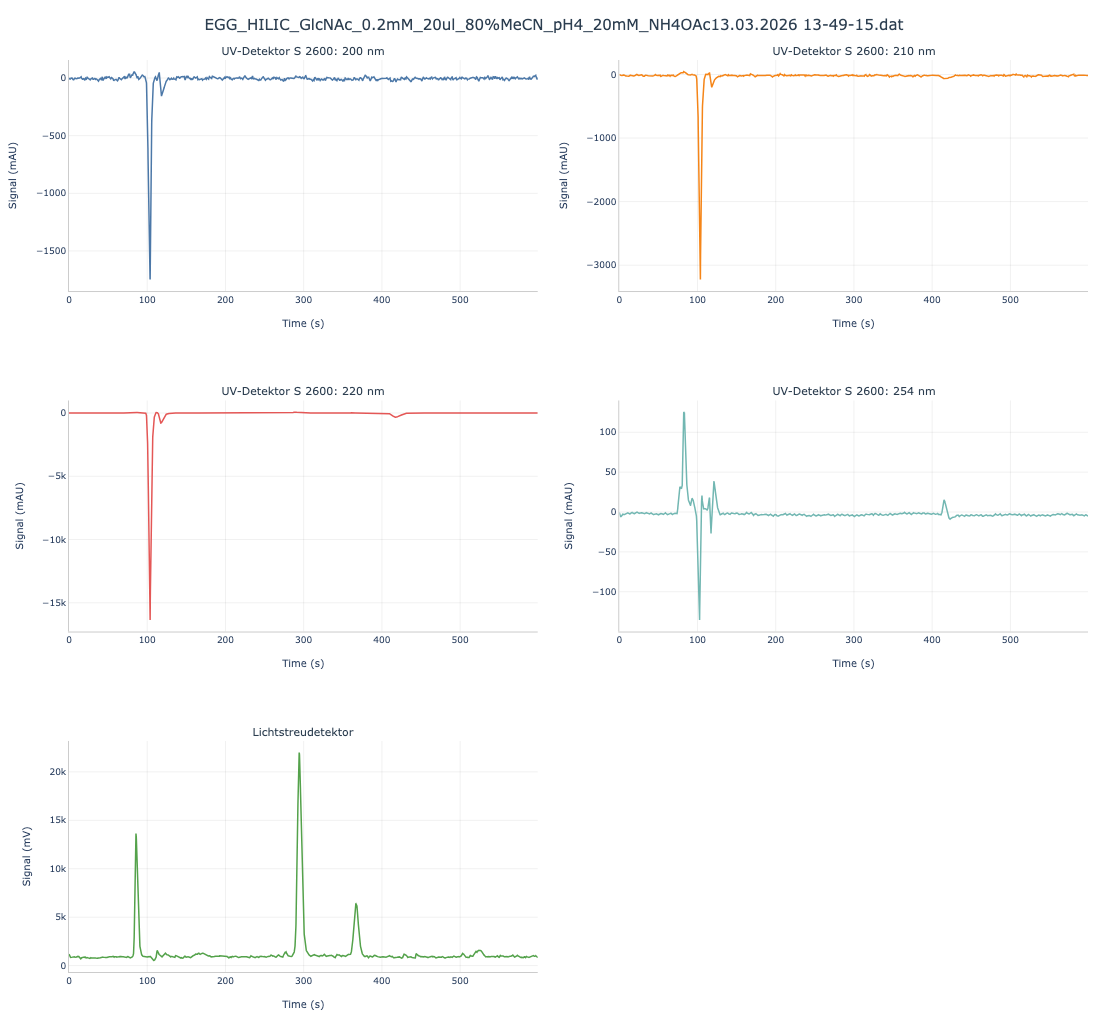

KeyboardInterrupt: 

In [3]:
HPLC.load("./data/EGG_HILIC_GlcNAc_0.2mM_20ul_80%MeCN_pH4_20mM_NH4OAc13.03.2026 13-49-15.dat").display().detect_peaks().display()